# Regime Filter — Proof of Concept (Adaptive)

**Goal:** Test whether P3's GMM regime labels can improve Portfolio B strategies'
risk-adjusted returns via an adaptive per-strategy exposure multiplier.

**Not a strategy.** Does not generate trades. Takes each Portfolio B strategy's
base daily equity curve and scales each day's return by a regime-dependent factor,
producing a modified equity curve for comparison.

**Why adaptive?** Different strategies likely thrive in different regimes (a mean-
reversion strategy may prefer high-volatility regimes, a trend-follower may prefer
low-vol trending regimes). A single universal mapping would be wrong for some.
Instead we let each strategy's own data determine which regime is best for it,
then apply `aggressive_expansion`-style multipliers:

- **Best regime:** 1.5× (lean into it)
- **Middle regime(s):** 1.0× (neutral)
- **Worst regime:** 0.5× (risk off)

**Two analyses in this notebook:**

### Part A — In-sample regime ranking (upper bound)
Rank each strategy's regime performance using **full history**. Apply multipliers
based on that ranking. Measure improvement. **This is in-sample optimization** —
the filter "knows" which regime was best for each strategy. Use as an **upper bound**
on what the filter could achieve with perfect regime ranking.

### Part B — Walk-forward regime ranking (honest)
At each date, rank regimes using **only past data**. Apply the resulting multiplier
for that day only. Fully out-of-sample. More conservative (especially early in
the sample when ranking is based on thin data) but represents what could actually
be implemented live.

**Interpretation:**
- If Part A improvements are small → filter isn't worth building (ceiling is low)
- If Part A is strong but Part B collapses → the edge was in-sample fitting, not a real signal
- If Part B holds up → promising for PM-layer integration

**Strategies tested:** All available Portfolio B strategies (base `simple_bet_85pct_1x.csv`).
Missing strategies are skipped gracefully.

## 1. Setup

In [9]:
import sys
sys.path.insert(0, "../..")

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.mixture import GaussianMixture

import warnings
warnings.filterwarnings('ignore')

pd.set_option("display.max_columns", None)


In [10]:
# ── Config ──
DATA_DIR = "./data"  # P1's output (monthly_panel_transformed.csv, quarterly_...)

# P3 GMM hyperparameters (fixed from P3 best)
N_REGIMES      = 3
N_PCA          = 10
COV_TYPE       = "full"
REFIT_EVERY    = 24
INIT_TRAIN_PCT = 0.50

# Portfolio B strategies — each tested against its simple_bet 85% 1x daily equity CSV.
# Adjust paths if folder structure differs. Missing entries are skipped.
PORTFOLIO_B_STRATEGIES = {
    "IBS MR":           "../ibs_mean_reversion/results/ibs_mean_reversion_daily_equity/simple_bet_85pct_1x.csv",
    "Donchian":         "../donchian_channel/results/donchian_channel_daily_equity/simple_bet_85pct_1x.csv",
    "Bollinger":        "../bollinger_band/results/bollinger_band_daily_equity/simple_bet_85pct_1x.csv",
    "VIX MR":           "../vix_mean_reversion/results/vix_mean_reversion_daily_equity/simple_bet_85pct_1x.csv",
    "VIX ETN Dual":     "../vix_etn_dual/results/vix_etn_dual_daily_equity/simple_bet_85pct_1x.csv",
    "Sector Momentum":  "../sector_momentum/results/sector_momentum_daily_equity/simple_bet_85pct_1x.csv",
}

# Adaptive multiplier (aggressive expansion template)
MULT_BEST   = 1.5
MULT_MIDDLE = 1.0
MULT_WORST  = 0.5

STARTING_CAPITAL = 100_000

# Minimum past months required before walk-forward ranking is "trusted"
# Before this, we use neutral (1.0x) multipliers for all regimes.
WF_MIN_MONTHS_PER_REGIME = 6


## 2. Regenerate Regime Labels via P3 Walk-Forward

Re-runs P3's GMM walk-forward so regime labels themselves are out-of-sample.
Output: monthly regime labels from first prediction date onward.

In [11]:
# ── Load macro panel ──
monthly_macro   = pd.read_csv(f"{DATA_DIR}/monthly_panel_transformed.csv",
                                index_col=0, parse_dates=True)
quarterly_macro = pd.read_csv(f"{DATA_DIR}/quarterly_panel_transformed.csv",
                                index_col=0, parse_dates=True)
quarterly_ffill = quarterly_macro.resample("MS").ffill()
macro_panel = pd.concat([monthly_macro, quarterly_ffill], axis=1).ffill().bfill().fillna(0)
macro_panel = macro_panel.dropna(axis=1, how="all")
print(f"Macro panel: {macro_panel.shape}")

def compute_regime_labels(macro_panel, n_regimes, n_pca, cov_type,
                            refit_every, init_train_pct):
    N = len(macro_panel)
    init_train = int(N * init_train_pct)
    labels = []
    dates = []
    last_refit = -999
    scaler, pca, gmm = None, None, None

    for t in range(init_train, N):
        if t - last_refit >= refit_every or t == init_train:
            scaler = StandardScaler()
            X_scaled = scaler.fit_transform(macro_panel.iloc[:t])
            n_pca_safe = min(n_pca, X_scaled.shape[1], X_scaled.shape[0])
            pca = PCA(n_components=n_pca_safe)
            X_pca = pca.fit_transform(X_scaled)
            gmm = GaussianMixture(n_components=n_regimes, covariance_type=cov_type,
                                   n_init=10, random_state=42)
            gmm.fit(X_pca)
            last_refit = t
        x_now = pca.transform(scaler.transform(macro_panel.iloc[[t]]))
        labels.append(gmm.predict(x_now)[0])
        dates.append(macro_panel.index[t])

    return pd.Series(labels, index=pd.DatetimeIndex(dates), name="regime")

regime_monthly = compute_regime_labels(
    macro_panel, N_REGIMES, N_PCA, COV_TYPE, REFIT_EVERY, INIT_TRAIN_PCT)
print(f"Regime labels: {len(regime_monthly)} months, "
      f"{regime_monthly.index.min().date()} -> {regime_monthly.index.max().date()}")
print(f"Regime distribution: {dict(regime_monthly.value_counts().sort_index())}")


Macro panel: (502, 32)
Regime labels: 251 months, 2005-03-01 -> 2026-01-01
Regime distribution: {0: 78, 1: 59, 2: 114}


## 3. Load All Portfolio B Strategies

In [12]:
# ── Load each strategy's base daily equity; skip missing ──
strategies = {}
for name, path in PORTFOLIO_B_STRATEGIES.items():
    if not os.path.exists(path):
        print(f"  {name:<18s}: SKIP (file not found: {path})")
        continue
    try:
        df = pd.read_csv(path, index_col=0, parse_dates=True)
        if df.shape[1] == 1:
            eq = df.iloc[:, 0]
        else:
            col = "equity" if "equity" in df.columns else df.columns[0]
            eq = df[col]
        eq = eq.dropna()
        if len(eq) < 50:
            print(f"  {name:<18s}: SKIP (only {len(eq)} days of equity)")
            continue
        strategies[name] = eq
        total_ret = (eq.iloc[-1] / eq.iloc[0] - 1) * 100
        print(f"  {name:<18s}: {len(eq):>5d} days, "
              f"{eq.index.min().date()} -> {eq.index.max().date()}, "
              f"ret={total_ret:+.1f}%")
    except Exception as e:
        print(f"  {name:<18s}: ERROR loading: {e}")

print(f"\n{len(strategies)}/{len(PORTFOLIO_B_STRATEGIES)} strategies loaded")
if not strategies:
    raise RuntimeError("No strategies loaded — check file paths in PORTFOLIO_B_STRATEGIES")


  IBS MR            :  2668 days, 2016-01-08 -> 2026-03-31, ret=+191.1%
  Donchian          :  2624 days, 2016-02-23 -> 2026-03-13, ret=+147.6%
  Bollinger         :  2587 days, 2016-05-02 -> 2026-03-31, ret=+135.9%
  VIX MR            : SKIP (file not found: ../vix_mean_reversion/results/vix_mean_reversion_daily_equity/simple_bet_85pct_1x.csv)
  VIX ETN Dual      : SKIP (file not found: ../vix_etn_dual/results/vix_etn_dual_daily_equity/simple_bet_85pct_1x.csv)
  Sector Momentum   :  2522 days, 2016-08-01 -> 2026-03-31, ret=+1668.3%

4/6 strategies loaded


## 4. Helper: Stats + Per-Regime Analysis

In [13]:
def _stats(ret_series, starting=STARTING_CAPITAL):
    if len(ret_series) == 0 or ret_series.std() == 0:
        return {"total_return": 0.0, "cagr": 0.0, "sharpe": 0.0, "max_dd": 0.0,
                "equity": pd.Series(dtype=float)}
    eq = starting * (1 + ret_series).cumprod()
    total = (eq.iloc[-1] / starting - 1) * 100
    sharpe = ret_series.mean() / ret_series.std() * np.sqrt(252)
    years = (eq.index[-1] - eq.index[0]).days / 365.25
    cagr = ((eq.iloc[-1]/starting) ** (1/years) - 1) * 100 if years > 0 else 0
    peak = eq.expanding().max()
    max_dd = ((eq - peak) / peak).min() * 100
    return {
        "total_return": round(total, 1),
        "cagr":         round(cagr, 2),
        "sharpe":       round(sharpe, 2),
        "max_dd":       round(max_dd, 1),
        "equity":       eq,
    }

def _align_with_regimes(strategy_eq, regime_monthly):
    """Return (daily_returns, daily_regime_labels) aligned on common index."""
    proxy_ret = strategy_eq.pct_change().dropna()
    # Normalize indexes
    proxy_ret.index = pd.to_datetime(proxy_ret.index).tz_localize(None) \
        if proxy_ret.index.tz is not None else pd.to_datetime(proxy_ret.index)
    regime_idx = pd.to_datetime(regime_monthly.index)
    regime_adj = pd.Series(regime_monthly.values, index=regime_idx)
    # Reindex regime to daily, ffill
    regime_daily = regime_adj.reindex(proxy_ret.index, method="ffill").dropna()
    common_idx = proxy_ret.index.intersection(regime_daily.index)
    return proxy_ret.loc[common_idx], regime_daily.loc[common_idx].astype(int)


## 5. Part A — In-Sample Adaptive Filter (Upper Bound)

For each strategy:
1. Rank regimes by **full-history** average daily return
2. Apply multipliers: 1.5× in best regime, 1.0× in middle, 0.5× in worst
3. Compute filtered equity curve
4. Compare to unfiltered baseline

**Caveat:** This uses full-history ranking to decide the best/worst regime for each
strategy. The filter's multiplier on 2018-01-01 "knows" what the best regime was
over the entire 2005-2026 history. Results are the **ceiling** on what the filter
could achieve with perfect regime ranking. Real-world performance will be lower —
see Part B.

In [14]:
def apply_adaptive_filter_in_sample(proxy_ret, regime_labels,
                                      n_regimes=N_REGIMES,
                                      mult_best=MULT_BEST, mult_mid=MULT_MIDDLE,
                                      mult_worst=MULT_WORST):
    """Rank regimes by full-history mean return; apply multipliers accordingly."""
    regimes_present = sorted(regime_labels.unique())
    # Compute mean return per regime (full history)
    means = {r: proxy_ret[regime_labels == r].mean() for r in regimes_present}
    ranked = sorted(means.items(), key=lambda x: x[1], reverse=True)
    # Best → 1.5×, worst → 0.5×, middle(s) → 1.0×
    mapping = {}
    if len(ranked) == 1:
        mapping[ranked[0][0]] = 1.0
    else:
        mapping[ranked[0][0]] = mult_best
        mapping[ranked[-1][0]] = mult_worst
        for r, _ in ranked[1:-1]:
            mapping[r] = mult_mid
    mult = regime_labels.map(mapping).astype(float)
    filtered_ret = proxy_ret * mult
    return filtered_ret, mapping, means

results_A = {}

for name, eq in strategies.items():
    proxy_ret, regime_a = _align_with_regimes(eq, regime_monthly)
    if len(proxy_ret) < 50:
        print(f"  {name}: insufficient aligned data ({len(proxy_ret)} days), skipping")
        continue

    # Baseline (no filter)
    base_stats = _stats(proxy_ret)

    # Filtered
    filtered_ret, mapping, means = apply_adaptive_filter_in_sample(proxy_ret, regime_a)
    filt_stats = _stats(filtered_ret)

    # Per-regime stats for reporting
    regime_detail = {}
    for r in sorted(regime_a.unique()):
        sub = proxy_ret[regime_a == r]
        regime_detail[r] = {
            "n_days": int(len(sub)),
            "mean_daily_ret_bps": round(sub.mean() * 10000, 2),
            "sharpe_annualized": round(sub.mean()/sub.std()*np.sqrt(252), 2) if sub.std() > 0 else 0,
            "multiplier": round(mapping.get(r, 1.0), 2),
        }

    results_A[name] = {
        "baseline":       base_stats,
        "filtered":       filt_stats,
        "mapping":        mapping,
        "regime_detail":  regime_detail,
        "n_days":         len(proxy_ret),
    }

# Summary table
print("=" * 95)
print("PART A: IN-SAMPLE ADAPTIVE FILTER (Upper Bound)")
print("=" * 95)
print(f"{'Strategy':<18} {'Base Sh':>8} {'Filt Sh':>8} {'ΔSh':>7} "
      f"{'Base DD':>9} {'Filt DD':>9} {'ΔDD':>7} {'Base Ret':>10} {'Filt Ret':>10}")
print("-" * 95)
for name, r in results_A.items():
    b, f = r["baseline"], r["filtered"]
    d_sh = f["sharpe"] - b["sharpe"]
    d_dd = f["max_dd"] - b["max_dd"]
    print(f"{name:<18} {b['sharpe']:>8.2f} {f['sharpe']:>8.2f} {d_sh:>+7.2f} "
          f"{b['max_dd']:>+9.1f} {f['max_dd']:>+9.1f} {d_dd:>+7.1f} "
          f"{b['total_return']:>+9.1f}% {f['total_return']:>+9.1f}%")

# Aggregate
if results_A:
    mean_d_sh = np.mean([r["filtered"]["sharpe"] - r["baseline"]["sharpe"]
                          for r in results_A.values()])
    pos_count = sum(1 for r in results_A.values()
                    if r["filtered"]["sharpe"] > r["baseline"]["sharpe"])
    print("-" * 95)
    print(f"Mean Sharpe delta: {mean_d_sh:+.2f}  |  Strategies improved: {pos_count}/{len(results_A)}")


PART A: IN-SAMPLE ADAPTIVE FILTER (Upper Bound)
Strategy            Base Sh  Filt Sh     ΔSh   Base DD   Filt DD     ΔDD   Base Ret   Filt Ret
-----------------------------------------------------------------------------------------------
IBS MR                 1.32     1.32   +0.00      -7.9      -7.4    +0.5    +191.1%    +209.1%
Donchian               0.92     1.08   +0.16     -16.1     -12.7    +3.4    +147.6%    +203.4%
Bollinger              0.73     0.86   +0.13     -23.7     -23.7    +0.0    +135.9%    +163.2%
Sector Momentum        0.77     0.69   -0.08     -78.2     -93.5   -15.3   +1668.3%   +1049.5%
-----------------------------------------------------------------------------------------------
Mean Sharpe delta: +0.05  |  Strategies improved: 2/4


### Per-Strategy Regime Detail (Part A)

In [15]:
for name, r in results_A.items():
    print(f"\n{name} ({r['n_days']} days aligned)")
    print(f"  {'Regime':<8} {'Days':>6} {'Daily ret (bps)':>17} {'Sharpe (ann)':>14} {'Multiplier':>12}")
    for regime_id, detail in sorted(r["regime_detail"].items()):
        print(f"  {regime_id:<8} {detail['n_days']:>6} {detail['mean_daily_ret_bps']:>17.2f} "
              f"{detail['sharpe_annualized']:>14.2f} {detail['multiplier']:>12.2f}x")



IBS MR (2667 days aligned)
  Regime     Days   Daily ret (bps)   Sharpe (ann)   Multiplier
  0          1289              2.21           0.71         0.50x
  1           642              6.41           1.66         1.50x
  2           736              5.51           2.25         1.00x

Donchian (2623 days aligned)
  Regime     Days   Daily ret (bps)   Sharpe (ann)   Multiplier
  0          1289              0.49           0.12         0.50x
  1           615              7.77           1.60         1.50x
  2           719              5.82           1.89         1.00x

Bollinger (2586 days aligned)
  Regime     Days   Daily ret (bps)   Sharpe (ann)   Multiplier
  0          1289              1.92           0.45         0.50x
  1           604              4.08           0.55         1.00x
  2           693              6.43           1.97         1.50x

Sector Momentum (2521 days aligned)
  Regime     Days   Daily ret (bps)   Sharpe (ann)   Multiplier
  0          1289              7.

### Equity Curves (Part A)

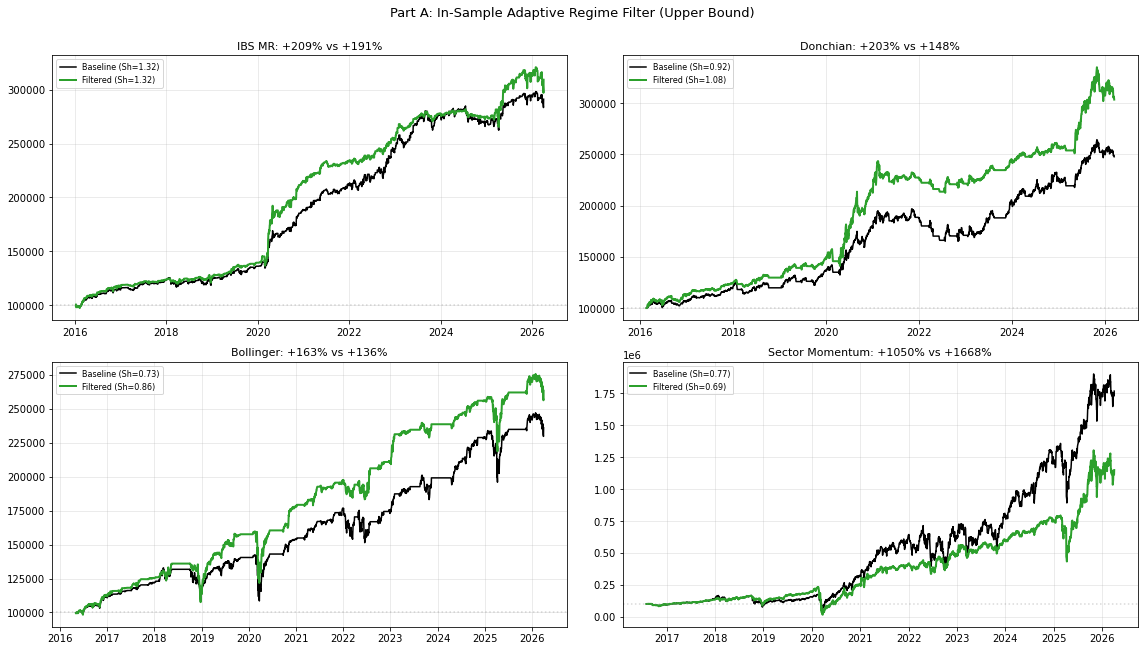

In [16]:
n = len(results_A)
if n > 0:
    ncols = min(2, n)
    nrows = int(np.ceil(n / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(8 * ncols, 4.5 * nrows))
    if n == 1:
        axes = np.array([axes])
    axes = axes.flatten()

    for i, (name, r) in enumerate(results_A.items()):
        ax = axes[i]
        base = r["baseline"]["equity"]
        filt = r["filtered"]["equity"]
        ax.plot(base.index.to_numpy(), base.values, "k-", linewidth=1.5,
                 label=f"Baseline (Sh={r['baseline']['sharpe']})")
        ax.plot(filt.index.to_numpy(), filt.values, "C2-", linewidth=2.0,
                 label=f"Filtered (Sh={r['filtered']['sharpe']})")
        ax.set_title(f"{name}: {r['filtered']['total_return']:+.0f}% vs {r['baseline']['total_return']:+.0f}%",
                      fontsize=11)
        ax.legend(fontsize=8); ax.grid(True, alpha=0.3)
        ax.axhline(STARTING_CAPITAL, color="gray", linestyle=":", alpha=0.3)

    for j in range(n, len(axes)):
        axes[j].set_visible(False)

    plt.suptitle("Part A: In-Sample Adaptive Regime Filter (Upper Bound)", fontsize=13, y=1.00)
    plt.tight_layout()
    plt.show()


## 6. Part B — Walk-Forward Adaptive Filter (Honest)

For each day of each strategy:
1. Use **only past data up to that day** to rank regimes by mean return
2. Apply the resulting multiplier to that day's return
3. Re-rank every month (or more frequently) as new data arrives

**Warm-up period:** Until each regime has observed at least `WF_MIN_MONTHS_PER_REGIME`
worth of data, we use neutral 1.0× multipliers. This prevents early-sample ranking
noise from dominating results.

This is what the filter could actually produce in a live setting. Expect weaker
results than Part A because:
- Early-sample rankings are noisy or undefined
- The filter has to decide multipliers before knowing how regimes would play out
- Some regime flips will be on the "wrong side" of mean-reversion in rankings

In [17]:
def apply_adaptive_filter_walk_forward(proxy_ret, regime_labels,
                                         min_days_per_regime=20,
                                         mult_best=MULT_BEST, mult_mid=MULT_MIDDLE,
                                         mult_worst=MULT_WORST):
    """
    For each day t, rank regimes using data [0:t], then apply multiplier for day t
    based on which regime day t is in.

    Multiplier at day t is based on mean returns per regime computed from strictly
    past days. If any regime has fewer than `min_days_per_regime` past observations,
    fall back to neutral 1.0x for all regimes on that day.
    """
    multipliers = np.ones(len(proxy_ret))
    regimes_arr = regime_labels.values
    rets_arr    = proxy_ret.values
    unique_regimes = sorted(regime_labels.unique())

    # Per-regime cumulative sums (up to but not including day t)
    regime_sums   = {r: 0.0 for r in unique_regimes}
    regime_counts = {r: 0   for r in unique_regimes}

    for t in range(len(proxy_ret)):
        # Decide multiplier for day t using PAST data only
        if all(regime_counts[r] >= min_days_per_regime for r in unique_regimes):
            # Rank regimes by past mean return
            means = {r: regime_sums[r] / regime_counts[r] for r in unique_regimes}
            ranked = sorted(means.items(), key=lambda x: x[1], reverse=True)
            mapping = {ranked[0][0]: mult_best, ranked[-1][0]: mult_worst}
            for rmid, _ in ranked[1:-1]:
                mapping[rmid] = mult_mid
            multipliers[t] = mapping.get(regimes_arr[t], mult_mid)
        else:
            multipliers[t] = 1.0  # warm-up: no filtering

        # Update cumulative stats AFTER using them for day t (no leakage)
        r_today = regimes_arr[t]
        regime_sums[r_today]   += rets_arr[t]
        regime_counts[r_today] += 1

    filtered_ret = proxy_ret * multipliers
    return filtered_ret, multipliers

results_B = {}

for name, eq in strategies.items():
    proxy_ret, regime_a = _align_with_regimes(eq, regime_monthly)
    if len(proxy_ret) < 100:
        continue

    base_stats = _stats(proxy_ret)
    filtered_ret, mults = apply_adaptive_filter_walk_forward(
        proxy_ret, regime_a,
        min_days_per_regime=WF_MIN_MONTHS_PER_REGIME * 21)  # months -> trading days
    filt_stats = _stats(filtered_ret)

    # Diagnostics
    n_warmup    = int((mults == 1.0).sum()) if np.isclose(MULT_MIDDLE, 1.0) else None
    # More accurate: count days where multiplier != typical post-warmup values
    post_warmup_multipliers = mults[-100:] if len(mults) > 100 else mults
    results_B[name] = {
        "baseline":       base_stats,
        "filtered":       filt_stats,
        "multipliers":    pd.Series(mults, index=proxy_ret.index),
        "n_days":         len(proxy_ret),
        "mean_mult":      float(np.mean(mults)),
        "warmup_days":    int((pd.Series(mults).diff().abs() == 0).cumsum().idxmax()) if len(mults) > 10 else 0,
    }

# Summary table
print("=" * 95)
print("PART B: WALK-FORWARD ADAPTIVE FILTER (Honest)")
print("=" * 95)
print(f"{'Strategy':<18} {'Base Sh':>8} {'WF Sh':>8} {'ΔSh':>7} "
      f"{'Base DD':>9} {'WF DD':>9} {'ΔDD':>7} {'Base Ret':>10} {'WF Ret':>10}")
print("-" * 95)
for name, r in results_B.items():
    b, f = r["baseline"], r["filtered"]
    d_sh = f["sharpe"] - b["sharpe"]
    d_dd = f["max_dd"] - b["max_dd"]
    print(f"{name:<18} {b['sharpe']:>8.2f} {f['sharpe']:>8.2f} {d_sh:>+7.2f} "
          f"{b['max_dd']:>+9.1f} {f['max_dd']:>+9.1f} {d_dd:>+7.1f} "
          f"{b['total_return']:>+9.1f}% {f['total_return']:>+9.1f}%")

if results_B:
    mean_d_sh_B = np.mean([r["filtered"]["sharpe"] - r["baseline"]["sharpe"]
                             for r in results_B.values()])
    pos_count_B = sum(1 for r in results_B.values()
                       if r["filtered"]["sharpe"] > r["baseline"]["sharpe"])
    print("-" * 95)
    print(f"Mean Sharpe delta: {mean_d_sh_B:+.2f}  |  Strategies improved: {pos_count_B}/{len(results_B)}")


PART B: WALK-FORWARD ADAPTIVE FILTER (Honest)
Strategy            Base Sh    WF Sh     ΔSh   Base DD     WF DD     ΔDD   Base Ret     WF Ret
-----------------------------------------------------------------------------------------------
IBS MR                 1.32     1.27   -0.05      -7.9      -7.4    +0.5    +191.1%    +199.7%
Donchian               0.92     0.98   +0.06     -16.1     -12.7    +3.4    +147.6%    +177.0%
Bollinger              0.73     0.56   -0.17     -23.7     -30.5    -6.8    +135.9%     +78.9%
Sector Momentum        0.77     0.79   +0.02     -78.2     -78.2    +0.0   +1668.3%   +1905.5%
-----------------------------------------------------------------------------------------------
Mean Sharpe delta: -0.04  |  Strategies improved: 2/4


### Equity Curves (Part B)

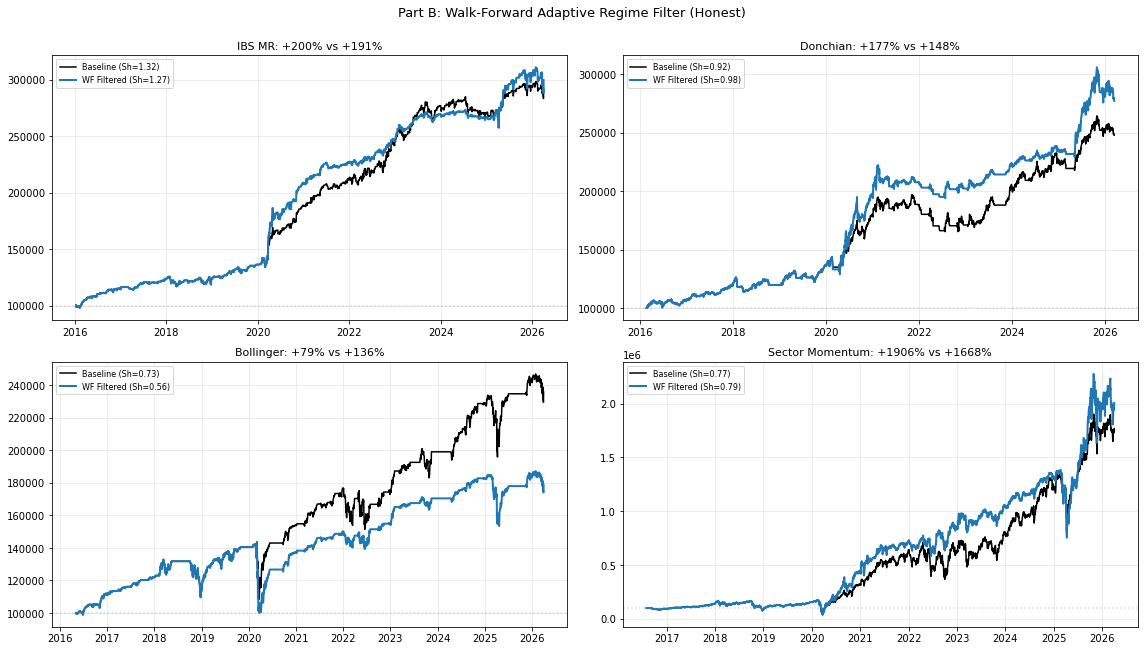

In [18]:
n = len(results_B)
if n > 0:
    ncols = min(2, n)
    nrows = int(np.ceil(n / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(8 * ncols, 4.5 * nrows))
    if n == 1:
        axes = np.array([axes])
    axes = axes.flatten()

    for i, (name, r) in enumerate(results_B.items()):
        ax = axes[i]
        base = r["baseline"]["equity"]
        filt = r["filtered"]["equity"]
        ax.plot(base.index.to_numpy(), base.values, "k-", linewidth=1.5,
                 label=f"Baseline (Sh={r['baseline']['sharpe']})")
        ax.plot(filt.index.to_numpy(), filt.values, "C0-", linewidth=2.0,
                 label=f"WF Filtered (Sh={r['filtered']['sharpe']})")
        ax.set_title(f"{name}: {r['filtered']['total_return']:+.0f}% vs {r['baseline']['total_return']:+.0f}%",
                      fontsize=11)
        ax.legend(fontsize=8); ax.grid(True, alpha=0.3)
        ax.axhline(STARTING_CAPITAL, color="gray", linestyle=":", alpha=0.3)

    for j in range(n, len(axes)):
        axes[j].set_visible(False)

    plt.suptitle("Part B: Walk-Forward Adaptive Regime Filter (Honest)", fontsize=13, y=1.00)
    plt.tight_layout()
    plt.show()


## 7. Side-by-Side Comparison: Part A vs Part B

The most important table in the notebook. For each strategy:
- Δ Sharpe under Part A (in-sample ceiling)
- Δ Sharpe under Part B (walk-forward reality)
- **Gap** = A − B. Large gap means the in-sample result was mostly optimization, not a
  real persistent signal. Small gap means the edge holds up out-of-sample.

In [19]:
common = sorted(set(results_A.keys()) & set(results_B.keys()))

print("=" * 85)
print("PART A vs PART B: How much of the upper-bound edge survives walk-forward?")
print("=" * 85)
print(f"{'Strategy':<18} {'Base Sh':>8} {'A Sh':>7} {'B Sh':>7} "
      f"{'ΔA':>6} {'ΔB':>6} {'Gap A-B':>8} {'Interpretation':<25}")
print("-" * 85)

summary_rows = []
for name in common:
    a = results_A[name]
    b = results_B[name]
    base_sh = a["baseline"]["sharpe"]
    a_sh = a["filtered"]["sharpe"]
    b_sh = b["filtered"]["sharpe"]
    d_a = a_sh - base_sh
    d_b = b_sh - base_sh
    gap = d_a - d_b

    if d_b >= 0.10:
        interp = "Real, useful signal"
    elif d_b >= 0.02:
        interp = "Modest real edge"
    elif d_b > -0.02:
        interp = "Neutral (noise)"
    else:
        interp = "Hurts performance"

    summary_rows.append({"strategy": name, "base_sh": base_sh,
                          "a_sh": a_sh, "b_sh": b_sh,
                          "delta_a": d_a, "delta_b": d_b, "gap": gap})

    print(f"{name:<18} {base_sh:>8.2f} {a_sh:>7.2f} {b_sh:>7.2f} "
          f"{d_a:>+6.2f} {d_b:>+6.2f} {gap:>+8.2f} {interp:<25}")

if summary_rows:
    mean_a = np.mean([r["delta_a"] for r in summary_rows])
    mean_b = np.mean([r["delta_b"] for r in summary_rows])
    pos_b = sum(1 for r in summary_rows if r["delta_b"] > 0)
    print("-" * 85)
    print(f"AGGREGATE: Mean ΔA={mean_a:+.2f}, Mean ΔB={mean_b:+.2f}, "
          f"B improved {pos_b}/{len(summary_rows)}")


PART A vs PART B: How much of the upper-bound edge survives walk-forward?
Strategy            Base Sh    A Sh    B Sh     ΔA     ΔB  Gap A-B Interpretation           
-------------------------------------------------------------------------------------
Bollinger              0.73    0.86    0.56  +0.13  -0.17    +0.30 Hurts performance        
Donchian               0.92    1.08    0.98  +0.16  +0.06    +0.10 Modest real edge         
IBS MR                 1.32    1.32    1.27  +0.00  -0.05    +0.05 Hurts performance        
Sector Momentum        0.77    0.69    0.79  -0.08  +0.02    -0.10 Modest real edge         
-------------------------------------------------------------------------------------
AGGREGATE: Mean ΔA=+0.05, Mean ΔB=-0.04, B improved 2/4


## 8. Final Verdict

In [20]:
print("=" * 70)
print("REGIME FILTER POC VERDICT")
print("=" * 70)

if not common:
    print("\nNo strategies available for analysis. Check PORTFOLIO_B_STRATEGIES paths.")
else:
    mean_a = np.mean([r["delta_a"] for r in summary_rows])
    mean_b = np.mean([r["delta_b"] for r in summary_rows])
    pos_b = sum(1 for r in summary_rows if r["delta_b"] > 0)
    pos_a = sum(1 for r in summary_rows if r["delta_a"] > 0)

    print(f"\nStrategies tested: {len(summary_rows)}")
    print(f"Mean ΔSharpe (Part A, in-sample ceiling): {mean_a:+.2f}")
    print(f"Mean ΔSharpe (Part B, walk-forward):      {mean_b:+.2f}")
    print(f"Strategies improved out-of-sample:        {pos_b}/{len(summary_rows)}")

    print("\nInterpretation:")
    if mean_b >= 0.10 and pos_b >= 0.66 * len(summary_rows):
        print("  ==> PROMISING. Walk-forward filter improves most strategies meaningfully.")
        print("      Next step: integrate into PM layer as exposure modulator.")
    elif mean_b >= 0.05 and pos_b >= 0.5 * len(summary_rows):
        print("  ==> MARGINAL. Small but consistent improvement.")
        print("      Consider integrating if implementation cost is low.")
        print("      Try tuning multipliers (MULT_BEST/MULT_WORST) before deciding.")
    elif mean_b > 0:
        print("  ==> WEAK. Positive average but inconsistent across strategies.")
        print("      May help some strategies only. Not a universal overlay.")
    else:
        print("  ==> REJECT. Walk-forward filter does not improve Portfolio B on average.")
        print(f"      Even if Part A showed +{mean_a:+.2f} ceiling, it's in-sample overfitting.")

    gap = mean_a - mean_b
    print(f"\nOverfitting gap (A - B) = {gap:+.2f}")
    if gap > 0.15:
        print("  Large gap: regime→performance relationship is unstable or sample-dependent.")
    elif gap > 0.05:
        print("  Moderate gap: some edge survives but in-sample fit overstates it.")
    else:
        print("  Small gap: in-sample and walk-forward agree — whatever edge exists is stable.")

    print("\nNOTE: Portfolio B has different characteristics across strategies (short vs")
    print("long vol, mean-rev vs trend). A universal multiplier may not fit all; a per-")
    print("strategy multiplier (computed from its own walk-forward regime ranking, as")
    print("done here) is already implemented in Part B.")


REGIME FILTER POC VERDICT

Strategies tested: 4
Mean ΔSharpe (Part A, in-sample ceiling): +0.05
Mean ΔSharpe (Part B, walk-forward):      -0.04
Strategies improved out-of-sample:        2/4

Interpretation:
  ==> REJECT. Walk-forward filter does not improve Portfolio B on average.
      Even if Part A showed ++0.05 ceiling, it's in-sample overfitting.

Overfitting gap (A - B) = +0.09
  Moderate gap: some edge survives but in-sample fit overstates it.

NOTE: Portfolio B has different characteristics across strategies (short vs
long vol, mean-rev vs trend). A universal multiplier may not fit all; a per-
strategy multiplier (computed from its own walk-forward regime ranking, as
done here) is already implemented in Part B.
